In [ ]:
from enum import Enum
import h5py
from glob import glob
import os
import matplotlib.pyplot as plt
import numpy as np
from math import floor

import re

def get_dataset_name(filenamewithdir):
    # print('Filename with directory:', filenamewithdir)
    return re.findall(r'/([a-zA-Z0-9_]+)_[0-9]*.h5', filenamewithdir)[0]

In [2]:
all_files = glob("../data/**/*.h5", recursive=True)
all_files

['../data/Intra/test/task_motor_105923_9.h5',
 '../data/Intra/test/rest_105923_9.h5',
 '../data/Intra/test/task_story_math_105923_9.h5',
 '../data/Intra/test/task_working_memory_105923_9.h5',
 '../data/Intra/test/task_motor_105923_10.h5',
 '../data/Intra/test/task_story_math_105923_10.h5',
 '../data/Intra/test/task_working_memory_105923_10.h5',
 '../data/Intra/test/rest_105923_10.h5',
 '../data/Intra/train/rest_105923_8.h5',
 '../data/Intra/train/task_story_math_105923_4.h5',
 '../data/Intra/train/task_motor_105923_8.h5',
 '../data/Intra/train/task_story_math_105923_1.h5',
 '../data/Intra/train/task_story_math_105923_5.h5',
 '../data/Intra/train/task_working_memory_105923_5.h5',
 '../data/Intra/train/task_motor_105923_7.h5',
 '../data/Intra/train/rest_105923_2.h5',
 '../data/Intra/train/rest_105923_6.h5',
 '../data/Intra/train/task_working_memory_105923_1.h5',
 '../data/Intra/train/task_motor_105923_3.h5',
 '../data/Intra/train/rest_105923_7.h5',
 '../data/Intra/train/task_motor_105923

## Test that all files have the same shape

In [3]:
all_good = True
for file_path in all_files:
    with h5py.File(file_path, 'r') as f:
        datasetname = get_dataset_name(file_path)
        # print('Dataset name:', datasetname)
        
        # print(f.keys())
        matrix = f.get(datasetname)[()]
        # print(type(matrix))
        if str(matrix.shape).strip() != "(248, 35624)":
            all_good = False
            print('Different shape for file:', file_path)
            print('\tGot', matrix.shape, 'but expected (248, 35624)')
        
if all_good:
    print("All files have the same, expcted shape")
else:
    print("Some files have a different shape")

All files have the same, expcted shape


In [136]:
file_path = all_files[2]
print('loading file:', file_path)
with h5py.File(file_path, 'r') as f:
    datasetname = get_dataset_name(file_path)
    # print('Dataset name:', datasetname)
    
    # print(f.keys())
    matrix = f.get(datasetname)[()]
    # print(type(matrix))
    if str(matrix.shape).strip() != "(248, 35624)":
        all_good = False
        print('Different shape for file:', file_path)
        print('\tGot', matrix.shape, 'but expected (248, 35624)')

np.min(matrix), np.max(matrix)

loading file: ../data/Intra/test/task_story_math_105923_9.h5


(np.float64(-1.1510461334074407e-10), np.float64(9.987316529347368e-12))

In [137]:
# Normalize matrix to be between 0 and 1
# matrix_norm = (matrix - np.min(matrix)) / (np.max(matrix) - np.min(matrix))
# matrix_norm = (matrix - np.min(matrix))# / np.std(matrix)
# matrix_norm = np.exp(matrix_norm) 
# matrix_norm /= np.std(matrix_norm)
matrix_norm = (matrix - np.mean(matrix)) / np.std(matrix)
# matrix_norm = np.exp(matrix_norm)

q_01, q25, q50, q75, q99 = np.quantile(matrix_norm, 0.01), np.quantile(matrix_norm, 0.25), np.quantile(matrix_norm, 0.5), np.quantile(matrix_norm, 0.75), np.quantile(matrix_norm, 0.99) 
np.min(matrix_norm), np.max(matrix_norm), np.mean(matrix_norm), np.std(matrix_norm)

(np.float64(-15.415288432998866),
 np.float64(1.2304987152664277),
 np.float64(-6.588488382409309e-18),
 np.float64(0.9999999999999999))

In [129]:
# matrix_norm = np.log(matrix_norm)

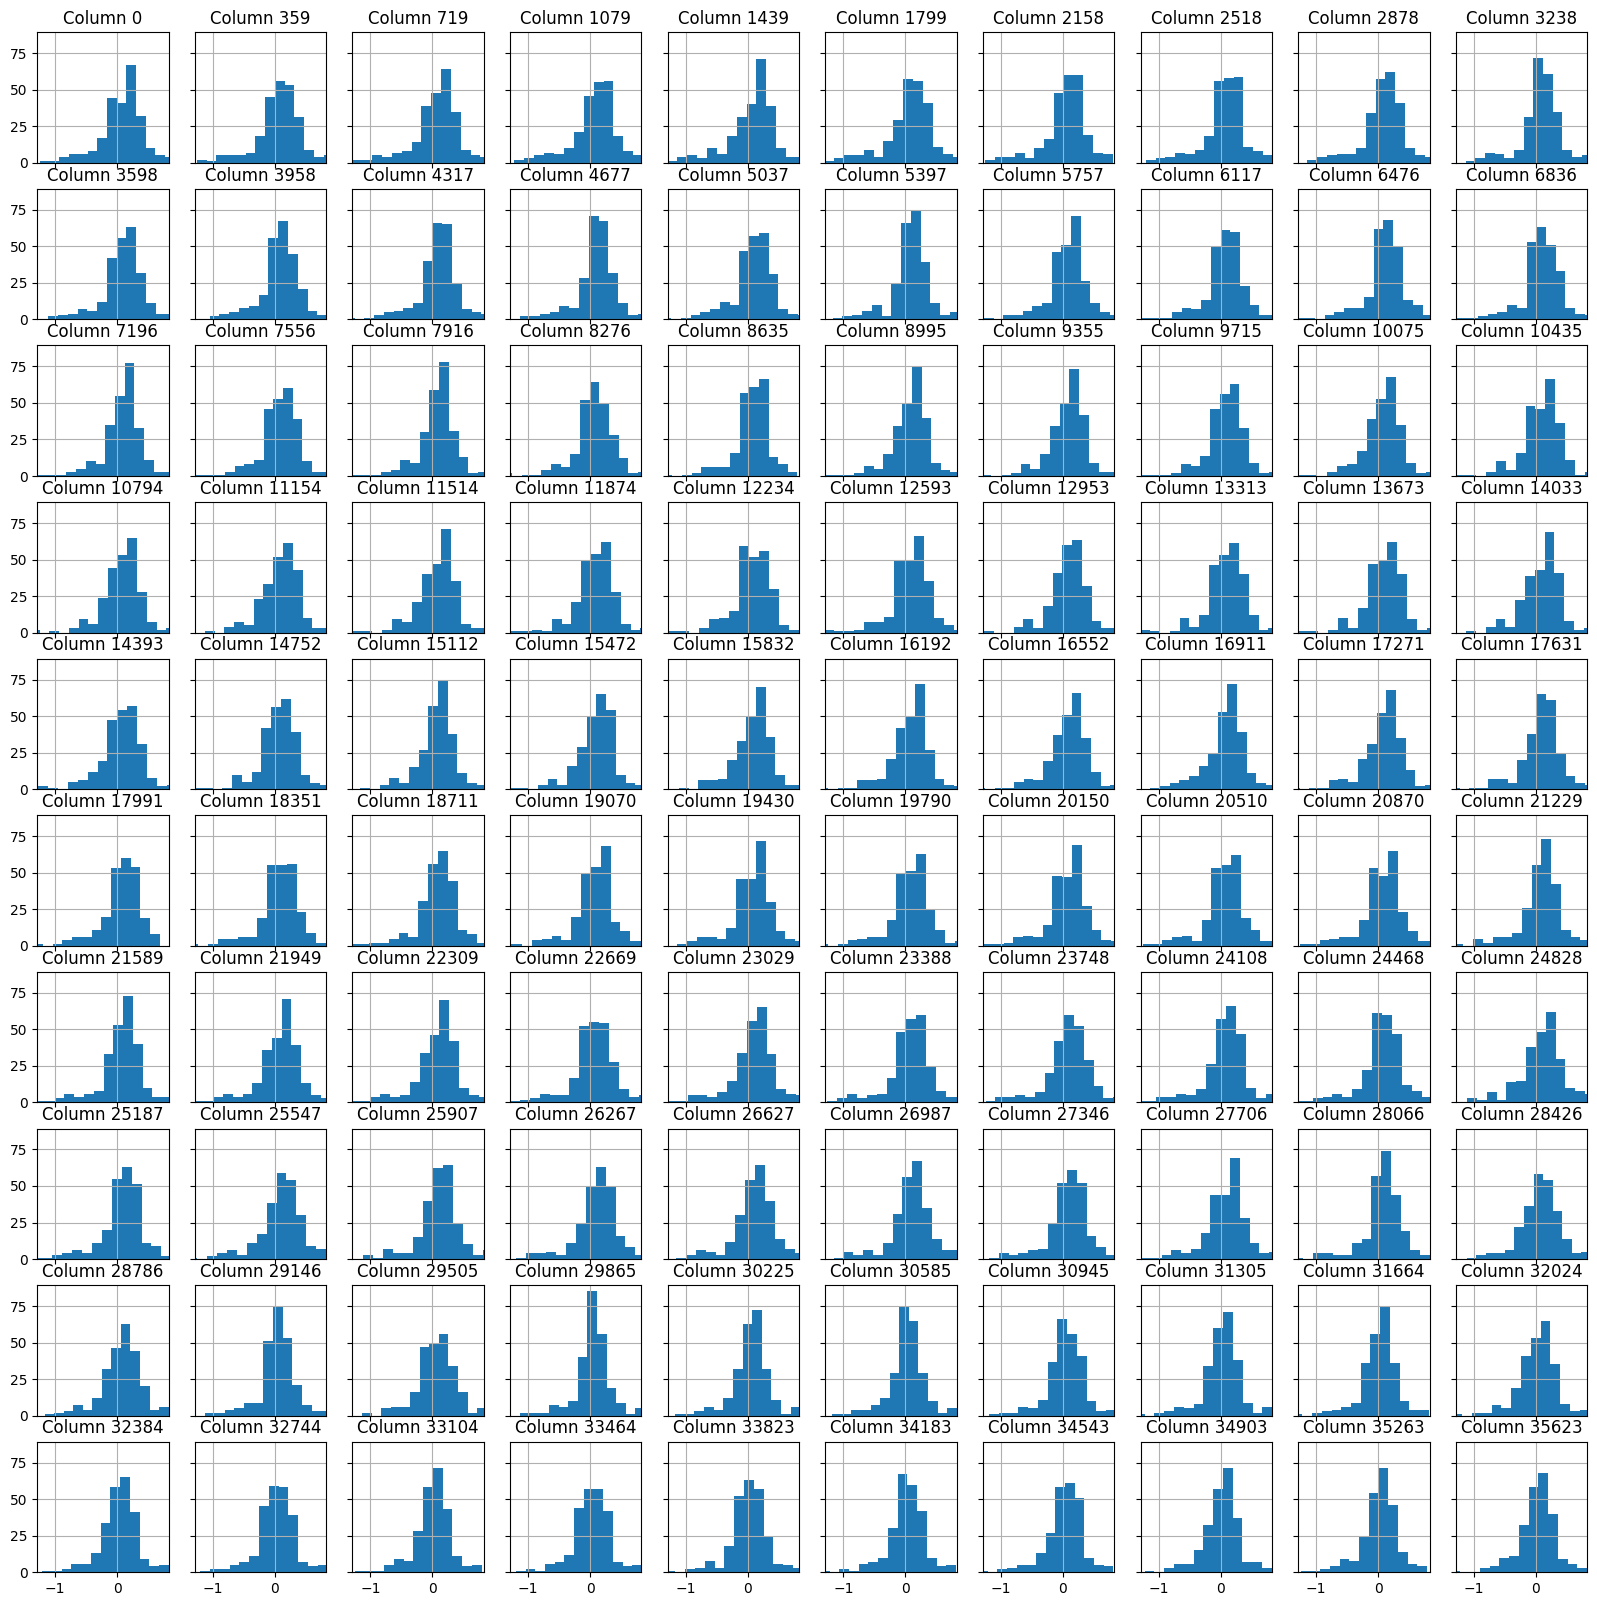

In [138]:
# histogram of the data in matrix
one_slice = matrix_norm[:, 1]

X = 10
Y = 10
NUM_SLICES = X * Y
NUM_BINS = 100

fig, ax = plt.subplots(X, Y, figsize=(2*X, 2*Y), sharex=True, sharey=True)

indices = np.linspace(0, matrix_norm.shape[1]-1, NUM_SLICES)

for x in range(X):
    for y in range(Y):
        index = floor(indices[x*Y + y])
        
        ax[x, y].hist(matrix_norm[:, index], bins=NUM_BINS)
        ax[x, y].grid(True)
        ax[x, y].set_title(f'Column {index}')
        
        ax[x, y].set_xlim(q_01, q99)
        
plt.show()
# plt.hist(one_slice, bins=100)
None

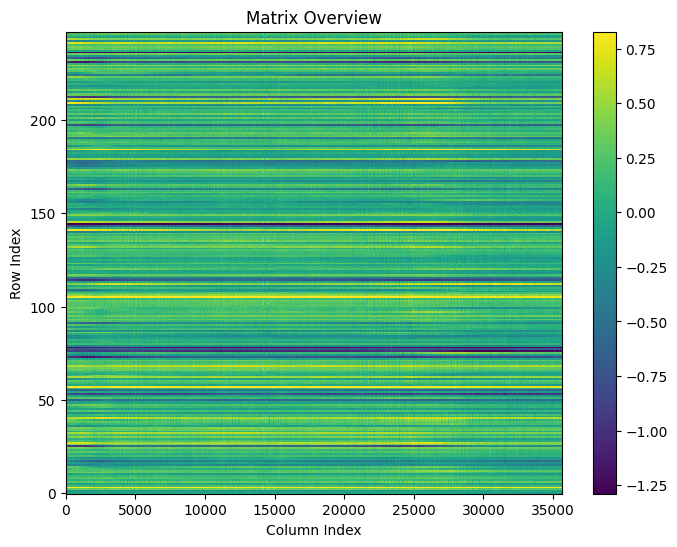

In [141]:
plt.figure(figsize=(8, 6))

# Set extent to cover the image; here, x spans matrix.shape[1], y spans matrix.shape[0]
# extent = [0, matrix.shape[1], 0, matrix.shape[0]]

# plot = plt.imshow(matrix, aspect='auto', origin='lower', interpolation='nearest')
plot = plt.imshow(matrix_norm, vmin=q_01, vmax=q99, aspect='auto', origin='lower', interpolation='nearest')
# plot = plt.imshow(matrix_norm, aspect='auto', origin='lower', interpolation='nearest')

plt.colorbar(plot)

ax = plt.gca()

# Example "peaks"; replace with real peaks if available
# peaks = np.array([[100, 1000], [150, 2000]])  # Dummy placeholder

# Uncomment and customize below if you have 'peaks'
# for i, peak in enumerate(peaks):
#     if i == 0:
#         ax.axhline(peak[0], color='red', linestyle='--', label='Peak')
#     else:
#         ax.axhline(peak[0], color='red', linestyle='--')
# ax.legend()

ax.set_xlabel('Column Index')
ax.set_ylabel('Row Index')
ax.set_title('Matrix Overview')

# ax.set_yscale('log')
# plt.savefig('test_unidec.png', dpi=300)

plt.show()